In [1]:
# === project setup ===
from pathlib import Path
import sys

PROJECT_ROOT = Path().resolve().parents[0]
print("PROJECT_ROOT =", PROJECT_ROOT)

if not (PROJECT_ROOT / "src").exists():
    raise RuntimeError("src directory not found — wrong PROJECT_ROOT")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

PROJECT_ROOT = C:\Users\hodor\Documents\lab-MSU\Works\2025.10_TMS\TEP_analysis


In [2]:
# === imports ===
import pandas as pd 
import numpy as np 
from h5py import File
import json
import os 

# graphics
import matplotlib.pyplot as plt 
import seaborn as sns
from mne.viz import plot_topomap
from matplotlib.patches import Patch
import matplotlib.gridspec as gridspec

In [8]:
from src.utils.montage_processing import *
filename_colors = r"../resources/channel_colors.json"
with open(filename_colors, "r") as f:
    EEG64_REGION_COLOR = json.load(f)
CED_FILE = r"../resources/mks64_standard.ced"
df = pd.read_csv(CED_FILE, sep='\t')
df["colors"] = df["labels"].map(EEG64_REGION_COLOR)
colors = df["colors"].values
positions = get_topo_positions(CED_FILE)

ROI_contra = ["C3", "C5", "C1", "CP3", "CP5", "CP1", "P5", "P3", "P1"]
ROI_idx = [find_ch_idx(ch, CED_FILE) for ch in ROI_contra]

In [3]:
def decode_matlab_string_payload(ds):
    arr = np.asarray(ds[()]).ravel().astype(np.uint64)

    ndims = int(arr[1])
    shape = tuple(int(x) for x in arr[2:2 + ndims])
    n_items = int(np.prod(shape))

    lengths_start = 2 + ndims
    lengths = [int(x) for x in arr[lengths_start:lengths_start + n_items]]
    packed = arr[lengths_start + n_items:]

    codes = []
    for value in packed:
        codes.extend(
            np.frombuffer(int(value).to_bytes(8, "little"), dtype="<u2").tolist()
        )

    strings = []
    pos = 0
    for length in lengths:
        strings.append("".join(chr(c) for c in codes[pos:pos + length]))
        pos += length

    return np.array(strings, dtype=object).reshape(shape, order="F")


def read_matlab_string(f, dataset_path):
    desc = np.asarray(f[dataset_path][()]).ravel()
    mcos_index = int(desc[4]) + 1
    ref = f["#subsystem#/MCOS"][()].ravel()[mcos_index]
    return decode_matlab_string_payload(f[ref])

In [26]:
import h5py

fn = r"..\data\exp\session_52__set_9__cleaned_SOUND.mat"

with h5py.File(fn, "r") as hdf:
    print(hdf.keys())
    print(hdf['cleanedResult'].keys())
    tvec = hdf['cleanedResult/tvec'][:][0]
    epoch  = hdf['cleanedResult/epochs_clean'][:] 

    orig = read_matlab_string(hdf, "cleanedResult/sourceDatasets/OriginalFile")
    orig = orig.ravel(order="F").tolist()

    label =  read_matlab_string(hdf, "cleanedResult/epoch_types")
    label = label.ravel(order="F").tolist()
    labels = np.asarray([json.loads(l)["stimulus"] for l in label])
    print(orig)

<KeysViewHDF5 ['#refs#', '#subsystem#', 'cleanedResult', 'summary']>
<KeysViewHDF5 ['Fs', 'analysisType', 'createdAt', 'dataRank', 'epoch_types', 'epochs_clean', 'final_projection_matrix', 'id', 'label', 'mep', 'pipeline', 'pipelineInputParameters', 'pipelineParameters', 'processVarargin', 'round1', 'round2', 'round2IcaFile', 'sound', 'sourceDatasetIndex', 'sourceDatasets', 'sourceIcaFile', 'sourceMetadata', 'tvec']>
['08_10ES_PPC_L_55MSO_real.hdf5']


In [27]:
epoch.shape, labels.shape

((64, 75, 4001), (75,))

In [28]:
def code_labels(labels, n):
    lab = np.zeros((n, 3))
    lab[np.where(labels == "animatedSingle1500_tms_+200ms_nosounds_bar.mkv"), 0] = 1
    lab[np.where(labels == "animatedSingle1500_tms_0ms_nosounds_bar.mkv"), 1] = 1
    lab[np.where(labels == "rest1500_tms_0ms_bar.mkv"), 2] = 1
    return lab

lab = code_labels(labels, epoch.shape[1])

In [29]:
rest_mask = np.where(lab[:, 2] == 1)[0]
onset_mask = np.where(lab[:, 1] == 1)[0]
after_mask = np.where(lab[:, 0] == 1)[0]

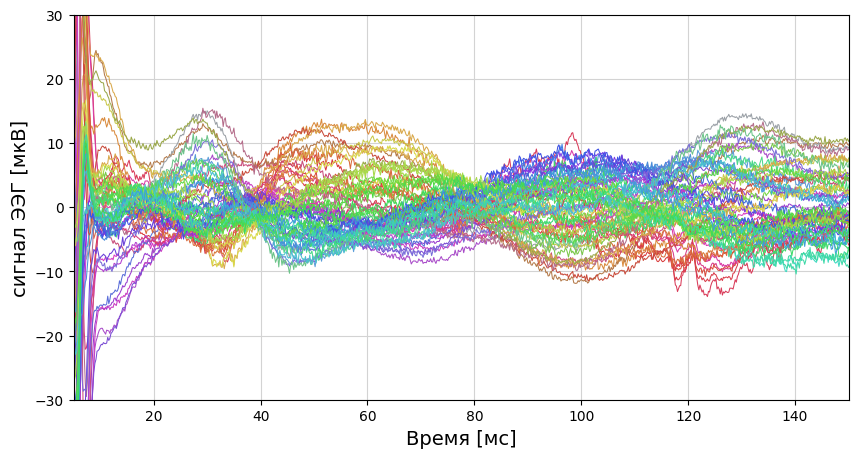

In [31]:
tmin, tmax = 5, 150
amp = 30

fig, ax = plt.subplots(1, 1, figsize=(10, 5))

TEPs = np.mean(epoch[:, rest_mask, :], axis=1)
for color, TEP in zip(colors, TEPs): # начало движения
    ax.plot(tvec, TEP, color=color, linewidth=.75)
ax.set_xlim(tmin, tmax)
ax.set_ylim(-amp, amp)
ax.set_xlabel("Время [мс]", fontsize=14)
ax.set_ylabel("сигнал ЭЭГ [мкВ]", fontsize=14)
ax.grid(color="lightgrey")

# ax.set_title('ТВП в М1 в момент выполнения движения', fontsize=18)

ax.axvline(0, color="black", linewidth=2)